## **Introduction**
The goal of this notebook is to train an efficientnet model

## **Library**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Library
import os
import sys
import joblib

import numpy as np
import pandas as pd
import random
import math
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import cv2
from PIL import Image

import time
from tqdm.auto import tqdm
from functools import partial
from contextlib import contextmanager

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
import torchvision.models as models
from torch.nn.parameter import Parameter
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import albumentations
from albumentations import (HueSaturationValue, CLAHE,Rotate, Compose, Normalize,
                            Resize, RandomResizedCrop, HorizontalFlip, VerticalFlip, ShiftScaleRotate, Transpose)
from albumentations.pytorch import ToTensorV2

#from torchvision.transforms.v2 import Compose, Normalize, ToTensor

import timm
import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#import effnet utils
sys.path.append('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/utils')
#import effnet_utils
from effnet_utils import *
import cfg_effnet as cfg


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## **Utils**

In [ ]:

def image_path_generation(row, base_path='/wmdd811k/images'):
    """
    Generate the full path to an image based on the dataset split and image name.

    Parameters:
    - row (pd.Series): A row with at least 'set' and 'image' fields.
    - base_path (str): The base directory containing the image folders.

    Returns:
    - str: Full path to the image file.
    """
    subfolder = row['set']
    return os.path.join(base_path, subfolder, row['image'])

def plot_label_distribution(df, label_col='labels', title='Label Distribution', figsize=(6, 4), color_map=plt.cm.tab10.colors, ylim_buffer=300):
    """
    Plot a bar chart of label distribution with annotations.

    Parameters:
    - df: pandas DataFrame containing the label column
    - label_col: name of the column containing the labels
    - title: title of the plot
    - figsize: size of the figure (width, height)
    - color_map: color map for the bars (e.g., plt.cm.tab10.colors)
    - ylim_buffer: extra space on top of bars to accommodate text
    """
    counts = df[label_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    ax = counts.plot(kind='bar', color=color_map[:len(counts)])

    # Annotate each bar with its count
    for index, value in enumerate(counts):
        ax.text(index, value + 5, f'{value}', ha='center', fontsize=10)

    plt.title(title)
    plt.xlabel('Labels')
    plt.ylabel('# of instances')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, counts.max() + ylim_buffer)
    plt.tight_layout()
    plt.show()

# ROC AUC per classe
#---------------------------------------------------------------------------------
def roc_auc_score_multiclass(actual_class, pred_class):
    unique_class = set(actual_class)
    roc_auc_dict = {}
    for c in unique_class:
        binary_actual = [1 if x == c else 0 for x in actual_class]
        binary_pred = [1 if x == c else 0 for x in pred_class]
        roc_auc_dict[c] = roc_auc_score(binary_actual, binary_pred)
    return roc_auc_dict

## **Data loading**

In [ ]:
# Define the base path for images
dataseet_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataseet_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataseet_path), axis=1)

df.shape

NameError: name 'pd' is not defined

In [ ]:
# Split the main DataFrame into separate datasets: train, val, test
datasets = {}
for split in ['train', 'val', 'test', 'cal']:
    subset = df[df['set'] == split].reset_index(drop=True)
    datasets[split] = subset
    print(f"{split} shape: {subset.shape}")

# Assign individual datasets for easier access
train = datasets['train']
valid = datasets['val']
test = datasets['test']
#cal = datasets['cal']

# Drop unnecessary columns from each dataset
cols_to_drop = ['wf_id', 'dieSize', 'lotid', 'image', 'set']
train = train.drop(cols_to_drop, axis=1)
valid = valid.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)
#cal = cal.drop(cols_to_drop, axis=1)


NameError: name 'df' is not defined

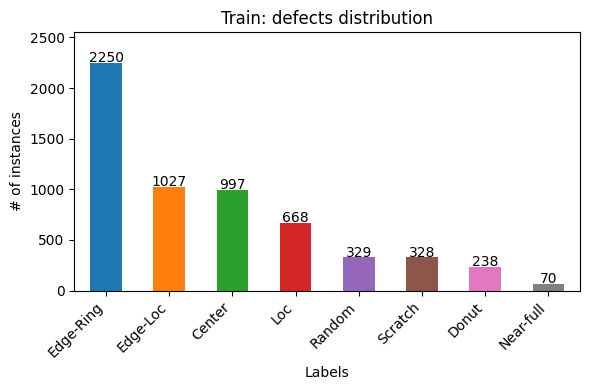

In [ ]:
plot_label_distribution(train, label_col='labels', title='Train: defects distribution')

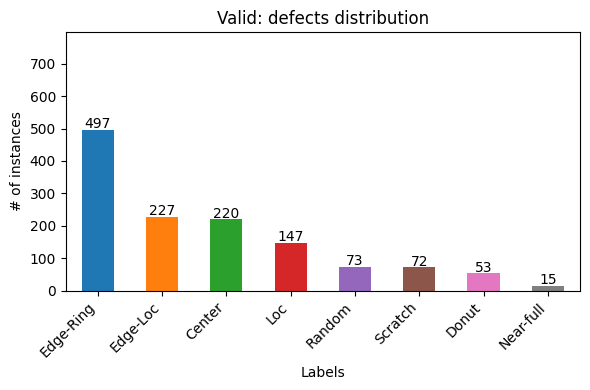

In [ ]:
plot_label_distribution(valid, label_col='labels', title='Valid: defects distribution')

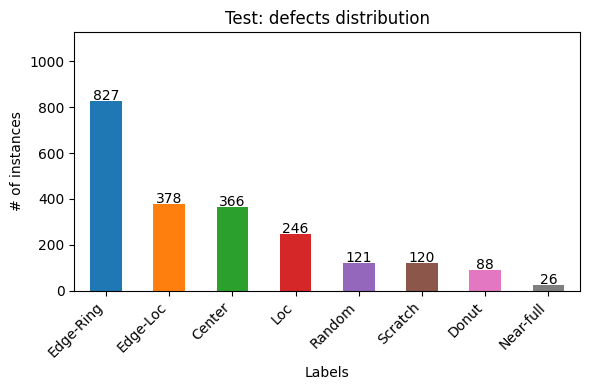

In [ ]:
plot_label_distribution(test, label_col='labels', title='Test: defects distribution')

In [ ]:
# labels encoding
label2int = {
    'Center': 0,
     'Donut': 1,
     'Edge-Loc': 2,
     'Edge-Ring': 3,
     'Loc': 4,
     'Random': 5,
     'Scratch': 6,
     'Near-full': 7}

train['labels']=train.labels.map(label2int)
valid['labels']=valid.labels.map(label2int)
test['labels']=test.labels.map(label2int)

print(np.sort(train['labels'].unique()))
print(np.sort(valid['labels'].unique()))
print(np.sort(test['labels'].unique()))

[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]


In [ ]:
# Image loading and preprocessing check
sample_image = cv2.imread(train.iloc[0]['image_id'])
print(type(sample_image))
print(sample_image.shape)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
print(type(sample_image))
print(sample_image.shape)
plt.imshow(sample_image)

NameError: name 'cv2' is not defined

## **Training**

In [ ]:
#cfg = CFG()
model_test = Model_type(cfg.model_name,cfg = cfg, pretrained=True)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
#cfg = CFG()
print('model name:', cfg.model_name)
print('number of clases:', cfg.target_size)
print('number of epochs:',cfg.epochs)
print('train size:',len(train))

model name: tf_efficientnet_b0_ns
number of clases: 8
number of epochs: 100
train size: 5907


========== start: training ==========
INFO:effnet_utils:========== start: training ==========


Epoch: [1][0/369] Data 16.229 (16.229) Elapsed 0m 18s (remain 115m 40s) Loss: 2.7819(2.7819) Grad: 13.3441  
Epoch: [1][100/369] Data 0.000 (0.732) Elapsed 1m 39s (remain 4m 24s) Loss: 0.3728(0.8947) Grad: 6.7135  
Epoch: [1][200/369] Data 1.357 (0.709) Elapsed 3m 11s (remain 2m 39s) Loss: 0.4254(0.7276) Grad: 6.2585  
Epoch: [1][300/369] Data 0.000 (0.659) Elapsed 4m 29s (remain 1m 0s) Loss: 0.2413(0.6129) Grad: 5.8645  
Epoch: [1][368/369] Data 0.436 (0.659) Elapsed 5m 29s (remain 0m 0s) Loss: 0.1773(0.5619) Grad: 3.8321  
EVAL: [0/82] Data 19.916 (19.916) Elapsed 0m 20s (remain 27m 1s) Loss: 0.1923(0.1923) 
EVAL: [81/82] Data 0.000 (0.946) Elapsed 1m 23s (remain 0m 0s) Loss: 0.1828(0.3031) 


Epoch 1 - avg_train_loss: 0.5619  avg_val_loss: 0.3031  time: 414s
INFO:effnet_utils:Epoch 1 - avg_train_loss: 0.5619  avg_val_loss: 0.3031  time: 414s
Epoch 1 - Accuracy: 0.8757668711656442 AUC: 0.9896752981316758
INFO:effnet_utils:Epoch 1 - Accuracy: 0.8757668711656442 AUC: 0.9896752981316758
Epoch 1 - Save Best Score: 0.9897 Model
INFO:effnet_utils:Epoch 1 - Save Best Score: 0.9897 Model


Epoch: [2][0/369] Data 2.527 (2.527) Elapsed 0m 2s (remain 16m 40s) Loss: 0.0922(0.0922) Grad: 1.9385  
Epoch: [2][100/369] Data 0.000 (0.028) Elapsed 0m 29s (remain 1m 18s) Loss: 0.1063(0.2038) Grad: 3.4818  
Epoch: [2][200/369] Data 0.000 (0.015) Elapsed 0m 55s (remain 0m 46s) Loss: 0.0600(0.1968) Grad: 1.8758  
Epoch: [2][300/369] Data 0.006 (0.011) Elapsed 1m 20s (remain 0m 18s) Loss: 0.2474(0.2061) Grad: 5.9067  
Epoch: [2][368/369] Data 0.000 (0.010) Elapsed 1m 38s (remain 0m 0s) Loss: 0.1461(0.2086) Grad: 4.5363  
EVAL: [0/82] Data 2.455 (2.455) Elapsed 0m 2s (remain 3m 26s) Loss: 0.0727(0.0727) 
EVAL: [81/82] Data 0.000 (0.089) Elapsed 0m 13s (remain 0m 0s) Loss: 0.1021(0.2552) 


Epoch 2 - avg_train_loss: 0.2086  avg_val_loss: 0.2552  time: 112s
INFO:effnet_utils:Epoch 2 - avg_train_loss: 0.2086  avg_val_loss: 0.2552  time: 112s
Epoch 2 - Accuracy: 0.9095092024539877 AUC: 0.9923792288709959
INFO:effnet_utils:Epoch 2 - Accuracy: 0.9095092024539877 AUC: 0.9923792288709959
Epoch 2 - Save Best Score: 0.9924 Model
INFO:effnet_utils:Epoch 2 - Save Best Score: 0.9924 Model


...

Epoch 9 - avg_train_loss: 0.0090  avg_val_loss: 0.2774  time: 113s
INFO:effnet_utils:Epoch 9 - avg_train_loss: 0.0090  avg_val_loss: 0.2774  time: 113s
Epoch 9 - Accuracy: 0.9233128834355828 AUC: 0.9948071820533281
INFO:effnet_utils:Epoch 9 - Accuracy: 0.9233128834355828 AUC: 0.9948071820533281


patience_count=5
Epoch: [10][0/369] Data 4.300 (4.300) Elapsed 0m 4s (remain 27m 18s) Loss: 0.0004(0.0004) Grad: 0.0275  
Epoch: [10][100/369] Data 0.000 (0.046) Elapsed 0m 31s (remain 1m 22s) Loss: 0.0027(0.0049) Grad: 0.2608  
Epoch: [10][200/369] Data 0.000 (0.024) Elapsed 0m 57s (remain 0m 47s) Loss: 0.0010(0.0047) Grad: 0.1201  
Epoch: [10][300/369] Data 0.000 (0.017) Elapsed 1m 23s (remain 0m 18s) Loss: 0.0153(0.0056) Grad: 1.0485  
Epoch: [10][368/369] Data 0.000 (0.014) Elapsed 1m 41s (remain 0m 0s) Loss: 0.0015(0.0058) Grad: 0.0706  
EVAL: [0/82] Data 2.565 (2.565) Elapsed 0m 2s (remain 3m 34s) Loss: 0.0038(0.0038) 
EVAL: [81/82] Data 0.000 (0.067) Elapsed 0m 11s (remain 0m 0s) Loss: 0.0058(0.2821) 


Epoch 10 - avg_train_loss: 0.0058  avg_val_loss: 0.2821  time: 114s
INFO:effnet_utils:Epoch 10 - avg_train_loss: 0.0058  avg_val_loss: 0.2821  time: 114s
Epoch 10 - Accuracy: 0.9263803680981595 AUC: 0.9946455681069672
INFO:effnet_utils:Epoch 10 - Accuracy: 0.9263803680981595 AUC: 0.9946455681069672


patience_count=6
***Max patience count 6 reached with AUC on valid set = 0.9946***


Score: 0.92101
INFO:effnet_utils:Score: 0.92101
========== CV ==========
INFO:effnet_utils:========== CV ==========
Score: 0.92101
INFO:effnet_utils:Score: 0.92101


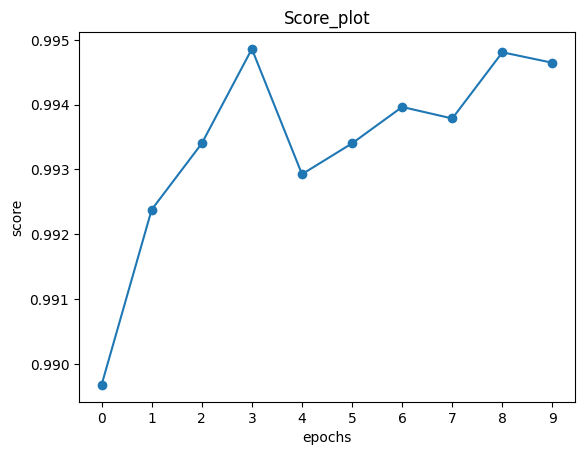

In [ ]:
main(cfg, train, valid)

## **Test Evaluation**

In [ ]:
# Setup e test loader
#--------------------------------------------------------------------------------------
test_dataset = TrainDataset(test, transform=get_transforms(data='valid', cfg=cfg))
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers, pin_memory=True)

In [ ]:
# Model loading
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model = Model_type(cfg.model_name, pretrained=False, cfg=cfg).to(device)
state_dict = torch.load('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models/tf_efficientnet_b0_ns_best.pth', weights_only=False)
model.load_state_dict(state_dict['model'])

<All keys matched successfully>

In [ ]:
# Inference
#---------------------------------------------------------------------------------
model.eval()
probs = []

for images in tqdm(test_loader, total=len(test_loader)):
    images = images[0].to(device)
    with torch.no_grad():
        logits = model(images)
        y_preds = logits.softmax(dim=1).cpu().numpy()
        probs.append(y_preds)

probs = np.concatenate(probs)
test['preds'] = probs.argmax(axis=1)

# --- Metriche ---
y_true = test['labels'].values
y_pred = test['preds'].values

  0%|          | 0/136 [00:00<?, ?it/s]

In [ ]:
# Labeling
#----------------------------------------------------------------------------------
labels = list(label2int.keys())
int2label = {v: k for k, v in label2int.items()}

# Accuracy e F1
#---------------------------------------------------------------------------------
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.3f}")
#print(f"Macro Recall: {recall_score(y_true, y_pred, average='macro'):.3f}")
#print(f"Micro Recall: {recall_score(y_true, y_pred, average='micro'):.3f}")
print(f"Macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.3f}")
#print(f"Micro F1 Score: {f1_score(y_true, y_pred, average='micro'):.3f}")

roc_auc_raw = roc_auc_score_multiclass(y_true, y_pred)
roc_auc_named = {int2label[k]: round(v, 2) for k, v in roc_auc_raw.items()}

print("-------------------------------------")
print("ROC AUC for each class:")
for label, score in roc_auc_named.items():
    print(f"{label}: {score}")


Overall Accuracy: 0.923
Macro F1 Score: 0.897
ROC AUC for each class:
Center: 0.97
Donut: 0.94
Edge-Loc: 0.94
Edge-Ring: 0.99
Loc: 0.85
Random: 0.96
Scratch: 0.93
Near-full: 0.98
